## 데이터 종류
- flowers : 꽃 개화 데이터 (2011년 - 2026년) - 원본
- flowers_subset - 분석용 데이터
- temp : 날씨 데이터 (2011.01.01.-2026.04.12.)

In [4]:
import pandas as pd

# 꽃 개화 데이터
flowers = pd.read_csv("data/seoul_flowers_2011_2026.csv", encoding="cp949")

# 기온 데이터 1
temp_1 = pd.read_csv("data/seoul_temp_2011_2020.csv", encoding="cp949")

# 기온 데이터 2
temp_2 = pd.read_csv("data/seoul_temp_2021_2026.csv", encoding="cp949")

# 기온 데이터 1,2 결합 -> temp (날씨 데이터 결합 )
temp = pd.concat([temp_1, temp_2], ignore_index=True)

In [7]:
display(flowers)
display(flowers.columns)

,지점,년도,개나리발아,개나리발아(평비),개나리개화,개나리개화(평비),개나리만발,개나리만발(평비),벚나무발아,벚나무발아(평비),벚나무개화,벚나무개화(평비),벚나무만발,벚나무만발(평비)
0,서울,2011,2011-03-22,4일,2011-04-05,8일,,,2011-04-01,8일,2011-04-13,5일,,
1,서울,2012,2012-03-20,2일,2012-04-04,7일,,,2012-04-02,9일,2012-04-15,7일,,
2,서울,2013,2013-03-18,0일,2013-04-03,6일,,,2013-04-03,10일,2013-04-15,7일,2013-04-18,8일
3,서울,2014,2014-03-17,-1일,2014-03-25,-3일,,,2014-03-23,-1일,2014-03-28,-11일,2014-03-31,-10일
4,서울,2015,2015-03-19,1일,2015-03-25,-3일,2015-04-01,-2일,2015-03-25,1일,2015-04-03,-5일,2015-04-06,-4일
5,서울,2016,2016-03-19,1일,2016-03-26,-2일,2016-03-31,-3일,2016-03-24,0일,2016-04-02,-6일,2016-04-05,-5일
6,서울,2017,2017-03-18,0일,2017-03-30,2일,2017-04-02,-1일,2017-03-25,1일,2017-04-06,-2일,2017-04-10,0일
7,서울,2018,2018-03-15,-3일,2018-03-27,-1일,2018-03-29,-5일,2018-03-27,3일,2018-04-02,-6일,2018-04-04,-6일
8,서울,2019,2019-03-09,-9일,2019-03-21,-7일,2019-03-27,-7일,2019-03-22,-2일,2019-04-03,-5일,2019-04-08,-2일
9,서울,2020,2020-03-13,-5일,2020-03-22,-6일,2020-03-26,-8일,2020-03-21,-3일,2020-03-27,-12일,2020-04-01,-9일


Index(['지점', '년도', '개나리발아', '개나리발아(평비)', '개나리개화', '개나리개화(평비)', '개나리만발',
       '개나리만발(평비)', '벚나무발아', '벚나무발아(평비)', '벚나무개화', '벚나무개화(평비)', '벚나무만발',
       '벚나무만발(평비)'],
      dtype='object')

### flowers 데이터프레임에서 분석에 필요한 컬럼만 선별
- '년도', '개나리개화', '벚나무개화' 컬럼 선별한 flowers_subset 데이터프레임 생성
- flowers_subset

In [5]:
# flowers_subset - 꽃 개화시기에 대한 분석용 데이터
flowers_subset = flowers[['년도', '개나리개화', '벚나무개화']].copy()
flowers_subset.columns = ['year', 'forsythia_bloom', 'cherry_bloom']
flowers_subset

,year,forsythia_bloom,cherry_bloom
0,2011,2011-04-05,2011-04-13
1,2012,2012-04-04,2012-04-15
2,2013,2013-04-03,2013-04-15
3,2014,2014-03-25,2014-03-28
4,2015,2015-03-25,2015-04-03
5,2016,2016-03-26,2016-04-02
6,2017,2017-03-30,2017-04-06
7,2018,2018-03-27,2018-04-02
8,2019,2019-03-21,2019-04-03
9,2020,2020-03-22,2020-03-27


### 분석에 필요한 최종 데이터프레임(flowers_subset_bloom) 생성
- 개나리개화, 벚나무개화 컬럼에 대해 타입을 날짜형으로 변환
- 날짜에 대해 년의 몇번째 일자인지 일수 세는 컬럼 생성 -> forsythia_doy, cherry_doy
- flowers_subset_bloom

In [6]:
# 복사본 생성
flowers_subset_bloom = flowers_subset.copy()

# 날짜형으로 변환
flowers_subset_bloom['forsythia_bloom'] = pd.to_datetime(flowers_subset_bloom['forsythia_bloom'])
flowers_subset_bloom['cherry_bloom'] = pd.to_datetime(flowers_subset_bloom['cherry_bloom'])

# 연중 일수(DOY) 컬럼 생성
flowers_subset_bloom['forsythia_doy'] = flowers_subset_bloom['forsythia_bloom'].dt.dayofyear
flowers_subset_bloom['cherry_doy'] = flowers_subset_bloom['cherry_bloom'].dt.dayofyear

# 분석에 필요한 컬럼만 선별해 사용하기
flowers_subset_bloom = flowers_subset_bloom[['year', 'forsythia_doy', 'cherry_doy']]
flowers_subset_bloom

,year,forsythia_doy,cherry_doy
0,2011,95,103
1,2012,95,106
2,2013,93,105
3,2014,84,87
4,2015,84,93
5,2016,86,93
6,2017,89,96
7,2018,86,92
8,2019,80,93
9,2020,82,87


### temp_1, temp_2 데이터프레임 하나로 결합
- temp 데이터프레임 생성

In [4]:
temp_1

,지점,지점명,일시,평균기온(°C)
0,108,서울,2011-01-01,-6.8
1,108,서울,2011-01-02,-5.4
2,108,서울,2011-01-03,-4.5
3,108,서울,2011-01-04,-3.9
4,108,서울,2011-01-05,-4.0
...,...,...,...,...
3648,108,서울,2020-12-27,5.8
3649,108,서울,2020-12-28,6.7
3650,108,서울,2020-12-29,0.1
3651,108,서울,2020-12-30,-10.9


In [5]:
temp_2

,지점,지점명,일시,평균기온(°C)
0,108,서울,2021-01-01,-4.2
1,108,서울,2021-01-02,-5.0
2,108,서울,2021-01-03,-5.6
3,108,서울,2021-01-04,-3.5
4,108,서울,2021-01-05,-5.5
...,...,...,...,...
1923,108,서울,2026-04-08,10.3
1924,108,서울,2026-04-09,10.6
1925,108,서울,2026-04-10,10.3
1926,108,서울,2026-04-11,10.9


In [7]:
temp

,지점,지점명,일시,평균기온(°C)
0,108,서울,2011-01-01,-6.8
1,108,서울,2011-01-02,-5.4
2,108,서울,2011-01-03,-4.5
3,108,서울,2011-01-04,-3.9
4,108,서울,2011-01-05,-4.0
...,...,...,...,...
5576,108,서울,2026-04-08,10.3
5577,108,서울,2026-04-09,10.6
5578,108,서울,2026-04-10,10.3
5579,108,서울,2026-04-11,10.9


### temp 데이터프레임에서 필요한 컬럼 선별
- '일시', '평균기온(°C)' 컬럼 선별한 temp_subset 데이터프레임 생성
- temp_subset

In [8]:
temp_subset = temp[['일시', '평균기온(°C)']].copy()
temp_subset.columns = ['date', 'avg_temp']
temp_subset

,date,avg_temp
0,2011-01-01,-6.8
1,2011-01-02,-5.4
2,2011-01-03,-4.5
3,2011-01-04,-3.9
4,2011-01-05,-4.0
...,...,...
5576,2026-04-08,10.3
5577,2026-04-09,10.6
5578,2026-04-10,10.3
5579,2026-04-11,10.9


### 분석에 필요한 최종 데이터프레임(temp_spring_yearly) 생성
- date 컬럼에 대해 타입을 날짜형으로 변환
- 전체기간에서 년도별 2,3,4월에 대한 행 선택
- date 컬럼에서 년도만 뽑아서 year 컬럼 생성
- 각 연도별 2,3,4월 전체 일평균기온의 평균값을 계산해 spring_avg_temp 컬럼생성
- temp_spring_yearly

In [9]:
# date 컬럼을 datetime 형식으로 변환
temp_subset['date'] = pd.to_datetime(temp_subset['date'])

# 각 년도에서 2월, 3월, 4월에 대한 행들만 선택 -> temp_spring이라는 데이터프레임 생성
temp_spring = temp_subset[temp_subset['date'].dt.month.isin([2, 3, 4])].copy()

# 초봄시기의 꽃 개화데이터 -> year 컬럼생성
temp_spring['year'] = temp_spring['date'].dt.year
# 각 연도별 2,3,4월 전체 일평균기온의 평균값을 계산
temp_spring.groupby('year')['avg_temp'].mean()

year
2011    5.257303
2012    5.207778
2013    4.771910
2014    8.061798
2015    7.011236
2016    7.177778
2017    6.822472
2018    6.674157
2019    6.866292
2020    7.188889
2021    8.785393
2022    7.285393
2023    8.782022
2024    9.080000
2025    6.935955
2026    6.614085
Name: avg_temp, dtype: float64

In [10]:
# 연도별 2~4월 평균기온 계산 → 새로운 데이터프레임 생성
temp_spring_yearly = temp_spring.groupby('year')['avg_temp'].mean().reset_index()

# 컬럼명 변경
temp_spring_yearly.columns = ['year', 'spring_avg_temp']

temp_spring_yearly

,year,spring_avg_temp
0,2011,5.257303
1,2012,5.207778
2,2013,4.771910
3,2014,8.061798
4,2015,7.011236
5,2016,7.177778
6,2017,6.822472
7,2018,6.674157
8,2019,6.866292
9,2020,7.188889


In [11]:
# date 컬럼을 datetime 형식으로 변환
temp_subset['date'] = pd.to_datetime(temp_subset['date'])

# 각 년도에서 3월, 4월에 대한 행들만 선택 -> temp_spring_34 데이터프레임 생성
temp_spring_34 = temp_subset[temp_subset['date'].dt.month.isin([3, 4])].copy()

# year 컬럼 생성
temp_spring_34['year'] = temp_spring_34['date'].dt.year

# 연도별 3~4월 평균기온 계산 → 새로운 데이터프레임 생성
temp_spring_34_yearly = temp_spring_34.groupby('year')['avg_temp'].mean().reset_index()

# 컬럼명 변경
temp_spring_34_yearly.columns = ['year', 'spring_avg_temp_34']

# 결과 확인
temp_spring_34_yearly

,year,spring_avg_temp_34
0,2011,7.109836
1,2012,8.655738
2,2013,7.531148
3,2014,10.877049
4,2015,9.750820
5,2016,10.498361
6,2017,10.067213
7,2018,10.493443
8,2019,9.565574
9,2020,9.401639


## 2개의 데이터프레임 병합하기
- 연도
- 개나리개화일
- 벚나무개화일
- 초봄 평균기온

### 일평균기온 평균값 -> 2,3,4월

In [12]:
# analysis_df : 개화일 + 날씨 결합한 분석용 데이터프레임명
analysis_df = pd.merge(flowers_subset_bloom, temp_spring_yearly, on='year', how='inner')

In [13]:
analysis_df

,year,forsythia_doy,cherry_doy,spring_avg_temp
0,2011,95,103,5.257303
1,2012,95,106,5.207778
2,2013,93,105,4.771910
3,2014,84,87,8.061798
4,2015,84,93,7.011236
5,2016,86,93,7.177778
6,2017,89,96,6.822472
7,2018,86,92,6.674157
8,2019,80,93,6.866292
9,2020,82,87,7.188889


### 일평균기온 평균값 -> 3,4월

In [14]:
# analysis_df : 개화일 + 날씨 결합한 분석용 데이터프레임명
analysis_df34 = pd.merge(flowers_subset_bloom, temp_spring_34_yearly, on='year', how='inner')
analysis_df34

,year,forsythia_doy,cherry_doy,spring_avg_temp_34
0,2011,95,103,7.109836
1,2012,95,106,8.655738
2,2013,93,105,7.531148
3,2014,84,87,10.877049
4,2015,84,93,9.750820
5,2016,86,93,10.498361
6,2017,89,96,10.067213
7,2018,86,92,10.493443
8,2019,80,93,9.565574
9,2020,82,87,9.401639


### 추가작업>> gap 컬럼 생성
- 기온이 올라감에 따라 개나리와 벚나무의 개화시기가 비슷해져 가는지 알아보고자.

In [15]:
analysis_df34['bloom_gap'] = analysis_df34['cherry_doy'] - analysis_df34['forsythia_doy']
analysis_df34

,year,forsythia_doy,cherry_doy,spring_avg_temp_34,bloom_gap
0,2011,95,103,7.109836,8
1,2012,95,106,8.655738,11
2,2013,93,105,7.531148,12
3,2014,84,87,10.877049,3
4,2015,84,93,9.750820,9
5,2016,86,93,10.498361,7
6,2017,89,96,10.067213,7
7,2018,86,92,10.493443,6
8,2019,80,93,9.565574,13
9,2020,82,87,9.401639,5


## 시각화

In [16]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

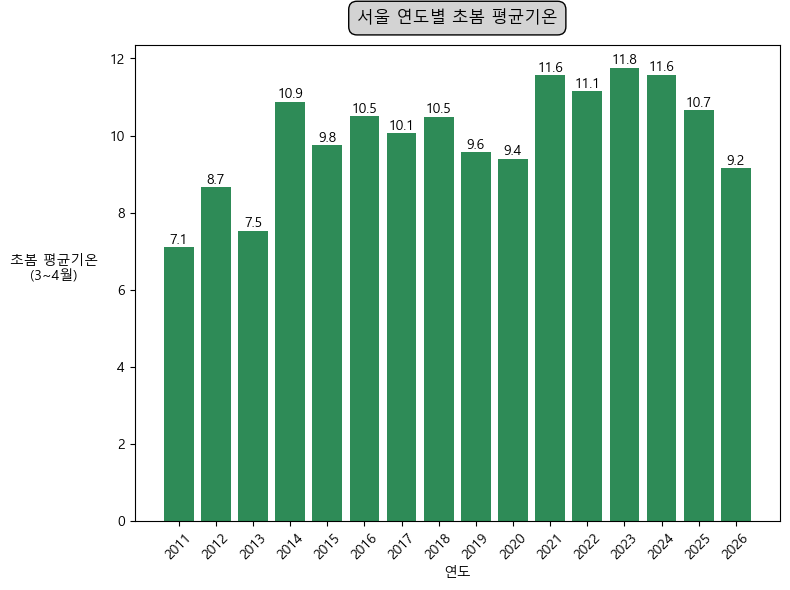

In [36]:
# 서울 연도별 초봄 평균기온 그래프

plt.figure(figsize=(8,6))

# 막대그래프
bars = plt.bar(
    analysis_df34['year'],
    analysis_df34['spring_avg_temp_34'],
    color='seagreen'
)

# 값 표시
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.1,
        f'{height:.1f}',
        ha='center'
    )

plt.xlabel('연도')
plt.ylabel('초봄 평균기온\n(3~4월)', rotation=0, labelpad=40)

plt.title(
    '서울 연도별 초봄 평균기온',
    y=1.03,
    bbox=dict(facecolor='lightgray', edgecolor='black', boxstyle='round,pad=0.5')
)

# 연도 전부 표시 + 보기 좋게
plt.xticks(analysis_df34['year'], rotation=45)

plt.tight_layout()
plt.show()

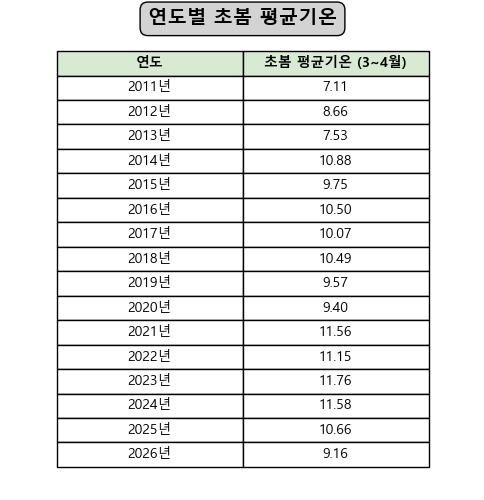

In [83]:
import matplotlib.pyplot as plt

# ======================
# 데이터 준비
# ======================
df_table = analysis_df34[['year', 'spring_avg_temp_34']].copy()

df_table['year'] = df_table['year'].astype(int).astype(str) + '년'
df_table['spring_avg_temp_34'] = df_table['spring_avg_temp_34'].map(lambda x: f'{x:.2f}')
df_table.columns = ['연도', '초봄 평균기온 (3~4월)']

# ======================
# 테이블 생성
# ======================
fig, ax = plt.subplots(figsize=(6, 6))
ax.axis('off')

table = ax.table(
    cellText=df_table.values,
    colLabels=df_table.columns,
    cellLoc='center',
    loc='center',
    bbox=[0.1, 0.05, 0.8, 0.90]
)

# ======================
# 🔥 스타일 설정
# ======================
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

# 🔥 컬럼 헤더 스타일 (배경색 + bold)
for (row, col), cell in table.get_celld().items():
    if row == 0:  # 헤더 행
        cell.set_facecolor('#D9EAD3')  # 연한 초록색
        cell.set_text_props(weight='bold')  # 글씨 bold

# ======================
# 🔥 제목 스타일 (bold + 박스)
# ======================
plt.title(
    '연도별 초봄 평균기온',
    fontsize=14,
    pad=3,
    weight='bold',  # 🔥 제목 bold
    bbox=dict(
        facecolor='lightgray',
        edgecolor='black',
        boxstyle='round,pad=0.4'
    )
)

plt.show()

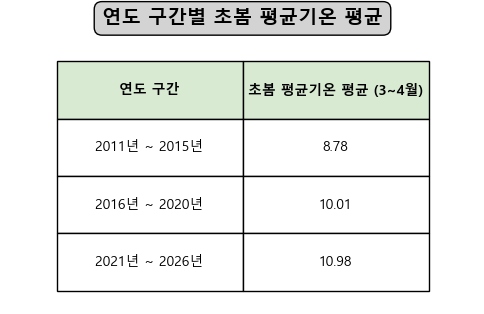

In [102]:
import pandas as pd
import matplotlib.pyplot as plt

# ======================
# 데이터 준비
# ======================
df_group = analysis_df34[['year', 'spring_avg_temp_34']].copy()

# 연도 구간 나누기
def year_group(year):
    if 2011 <= year <= 2015:
        return '2011년 ~ 2015년'
    elif 2016 <= year <= 2020:
        return '2016년 ~ 2020년'
    elif 2021 <= year <= 2026:
        return '2021년 ~ 2026년'
    else:
        return None

df_group['연도 구간'] = df_group['year'].apply(year_group)

# 필요한 구간만 남기기
df_group = df_group.dropna(subset=['연도 구간'])

# 구간별 평균 계산
df_table = (
    df_group.groupby('연도 구간', as_index=False)['spring_avg_temp_34']
    .mean()
)

# 소수점 포맷 적용
df_table['spring_avg_temp_34'] = df_table['spring_avg_temp_34'].map(lambda x: f'{x:.2f}')
df_table.columns = ['연도 구간', '초봄 평균기온 평균 (3~4월)']

# ======================
# 테이블 생성
# ======================
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.axis('off')

table = ax.table(
    cellText=df_table.values,
    colLabels=df_table.columns,
    cellLoc='center',
    loc='center',
    bbox=[0.1, 0.05, 0.8, 0.85]
)

# ======================
# 스타일 설정
# ======================
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.4)

# 헤더 스타일
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#D9EAD3')
        cell.set_text_props(weight='bold')

# 제목
plt.title(
    '연도 구간별 초봄 평균기온 평균',
    fontsize=14,
    pad=8,
    weight='bold',
    bbox=dict(
        facecolor='lightgray',
        edgecolor='black',
        boxstyle='round,pad=0.4'
    )
)

plt.show()

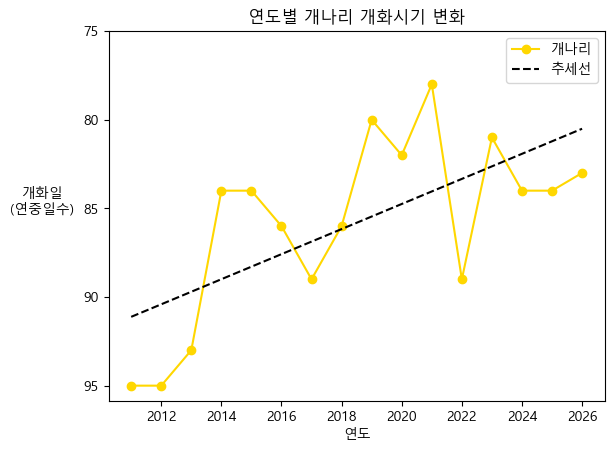

In [33]:
# 연도별 개나리 개화시기 변화 그래프

plt.figure()

# 데이터
plt.plot(
    analysis_df34['year'],
    analysis_df34['forsythia_doy'],
    color='gold',
    marker='o',
    label='개나리'
)

# 추세선
z = np.polyfit(analysis_df34['year'], analysis_df34['forsythia_doy'], 1)
p = np.poly1d(z)

plt.plot(
    analysis_df34['year'],
    p(analysis_df34['year']),
    color='black',
    linestyle='--',
    label='추세선'
)

plt.xlabel('연도')
plt.ylabel('개화일\n(연중일수)', rotation=0, labelpad=30)
plt.title('연도별 개나리 개화시기 변화')

# 🔥 y축 방향 뒤집기
plt.gca().invert_yaxis()

# 🔥 y축 값 정리
plt.yticks(range(75, 100, 5))

plt.legend()
plt.show()

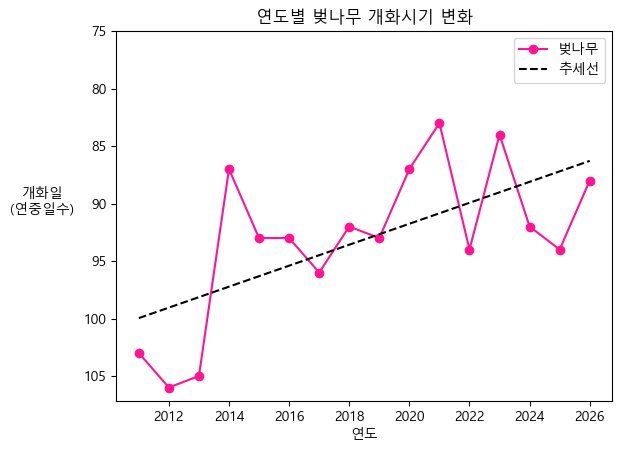

In [37]:
# 연도별 벚나무 개화시기 변화 그래프


plt.figure()

# 데이터
plt.plot(
    analysis_df34['year'],
    analysis_df34['cherry_doy'], 
    color='deeppink',             
    marker='o',
    label='벚나무'
)

# 추세선
z = np.polyfit(analysis_df34['year'], analysis_df34['cherry_doy'], 1)  
p = np.poly1d(z)

plt.plot(
    analysis_df34['year'],
    p(analysis_df34['year']),
    color='black',
    linestyle='--',
    label='추세선'
)

plt.xlabel('연도')
plt.ylabel('개화일\n(연중일수)', rotation=0, labelpad=30)
plt.title('연도별 벚나무 개화시기 변화')

# y축 방향 뒤집기
plt.gca().invert_yaxis()

# y축 값 정리
plt.yticks(range(75, 110, 5))  

plt.legend()
plt.show()

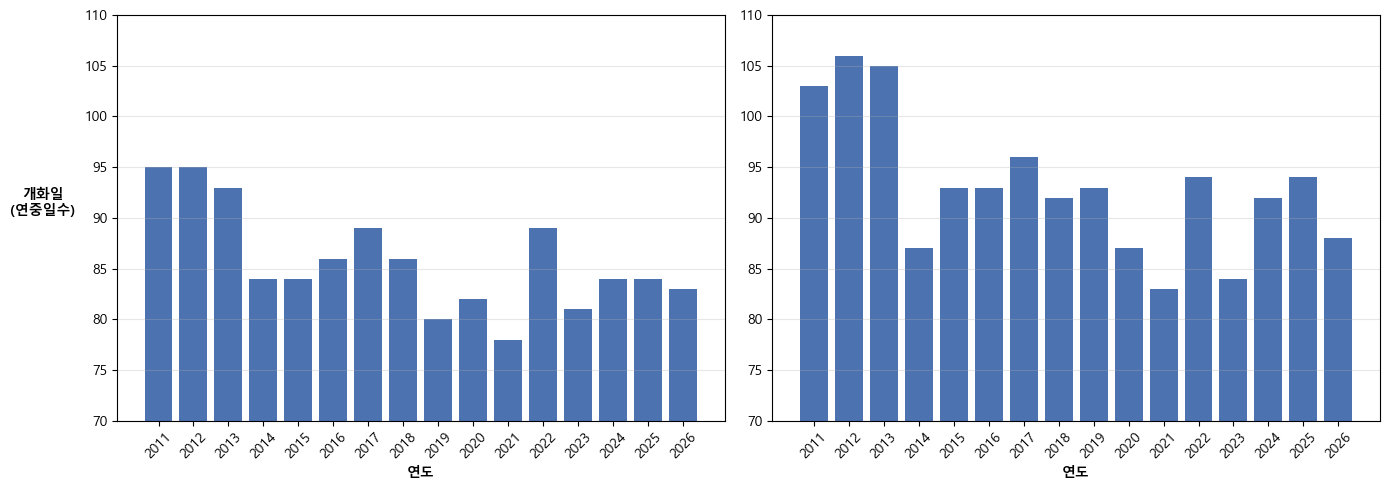

In [91]:
import matplotlib.pyplot as plt

# =======================
# 공통 설정
# =======================
years = analysis_df34['year']
color = '#4C72B0'  # 눈에 편한 블루톤

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# =======================
# 1. 개나리
# =======================
axes[0].bar(
    years,
    analysis_df34['forsythia_doy'],
    color=color
)

#axes[0].set_title('개나리')
axes[0].set_xlabel('연도', fontweight='bold')
axes[0].set_ylabel('개화일\n(연중일수)', rotation=0, labelpad=30, fontweight='bold')

# y축 범위 설정 (중요)
axes[0].set_ylim(70, 110)

# x축 연도 모두 표시
axes[0].set_xticks(years)
axes[0].tick_params(axis='x', rotation=45)

# grid 추가 (가독성)
axes[0].grid(axis='y', alpha=0.3)


# =======================
# 2. 벚나무
# =======================
axes[1].bar(
    years,
    analysis_df34['cherry_doy'],
    color=color
)

#axes[1].set_title('벚나무')
axes[1].set_xlabel('연도', fontweight='bold')

# y축 동일 범위 (비교 핵심)
axes[1].set_ylim(70, 110)

# x축 연도 모두 표시
axes[1].set_xticks(years)
axes[1].tick_params(axis='x', rotation=45)

# grid 추가
axes[1].grid(axis='y', alpha=0.3)

# =======================
# 레이아웃
# =======================
plt.tight_layout()
plt.show()

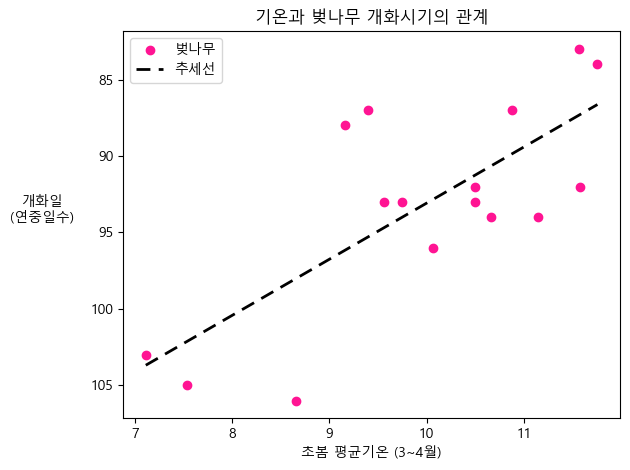

In [42]:
# 벚나무에서 기온과 개화시기의 상관관계

plt.figure()

# 산점도
plt.scatter(
    analysis_df34['spring_avg_temp_34'],
    analysis_df34['cherry_doy'],
    color='deeppink',
    label='벚나무'
)

# ======================
# 🔥 추세선 계산
# ======================
z = np.polyfit(
    analysis_df34['spring_avg_temp_34'],
    analysis_df34['cherry_doy'],
    1
)
p = np.poly1d(z)

# ======================
# 🔥 x값 정렬 (핵심)
# ======================
sorted_idx = np.argsort(analysis_df34['spring_avg_temp_34'])

x_sorted = analysis_df34['spring_avg_temp_34'].values[sorted_idx]
y_sorted = p(x_sorted)

# ======================
# 🔥 추세선 (점선 적용)
# ======================
plt.plot(
    x_sorted,
    y_sorted,
    color='black',
    linestyle=(0, (5, 3)),  # 커스텀 점선
    linewidth=2,
    label='추세선'
)

# 축 라벨
plt.xlabel('초봄 평균기온 (3~4월)')
plt.ylabel('개화일\n(연중일수)', rotation=0, labelpad=35)

# 제목
plt.title('기온과 벚나무 개화시기의 관계')

# y축 뒤집기 (작을수록 위)
plt.gca().invert_yaxis()

plt.legend()
plt.tight_layout()
plt.show()

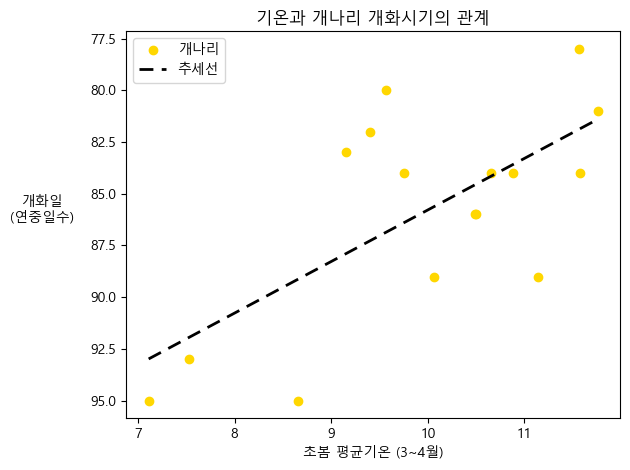

In [43]:
# 개나리에서 기온과 개화시기의 상관관계
plt.figure()

# 산점도
plt.scatter(
    analysis_df34['spring_avg_temp_34'],
    analysis_df34['forsythia_doy'],
    color='gold',
    label='개나리'
)

# ======================
# 추세선 계산
# ======================
z = np.polyfit(
    analysis_df34['spring_avg_temp_34'],
    analysis_df34['forsythia_doy'],
    1
)
p = np.poly1d(z)

# ======================
# x값 정렬
# ======================
sorted_idx = np.argsort(analysis_df34['spring_avg_temp_34'])

x_sorted = analysis_df34['spring_avg_temp_34'].values[sorted_idx]
y_sorted = p(x_sorted)

# ======================
# 추세선 (점선 적용)
# ======================
plt.plot(
    x_sorted,
    y_sorted,
    color='black',
    linestyle=(0, (5, 3)),
    linewidth=2,
    label='추세선'
)

# 축 라벨
plt.xlabel('초봄 평균기온 (3~4월)')
plt.ylabel('개화일\n(연중일수)', rotation=0, labelpad=35)

# 제목
plt.title('기온과 개나리 개화시기의 관계')

# y축 뒤집기 (작을수록 위)
plt.gca().invert_yaxis()

plt.legend()
plt.tight_layout()
plt.show()

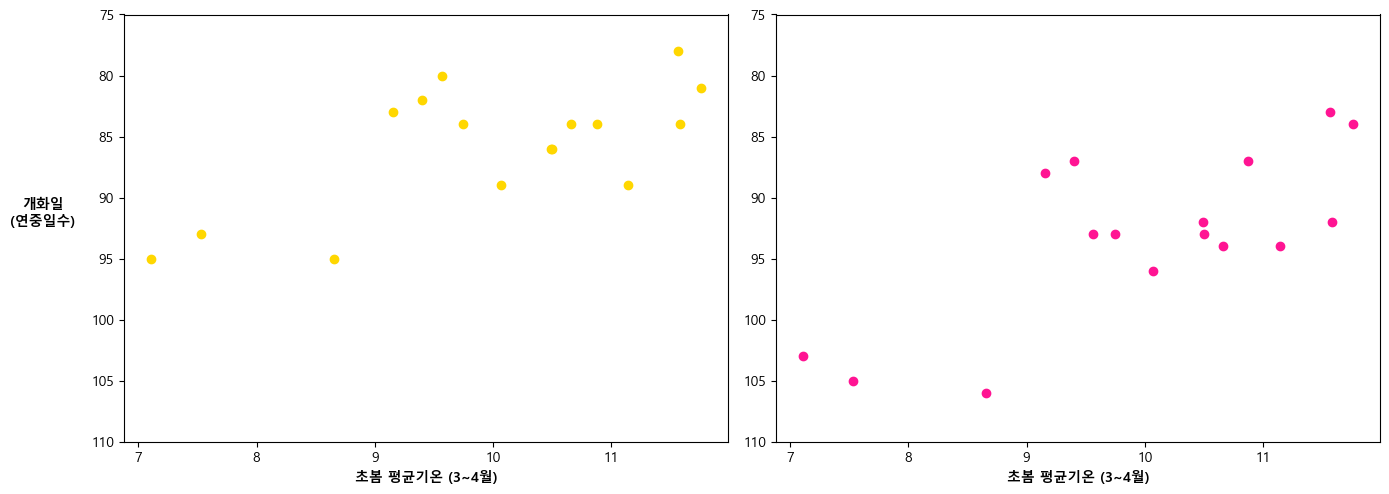

In [100]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 🔥 y축 범위 고정
y_min = 75
y_max = 110

# ======================
# 🔹 [왼쪽] 개나리
# ======================
ax = axes[0]

ax.scatter(
    analysis_df34['spring_avg_temp_34'],
    analysis_df34['forsythia_doy'],
    color='gold'
)

ax.set_xlabel('초봄 평균기온 (3~4월)', fontweight='bold')
ax.set_ylabel('개화일\n(연중일수)', rotation=0, labelpad=35, fontweight='bold')

# 🔥 y축 범위 + 방향
ax.set_ylim(y_max, y_min)

# ======================
# 🔹 [오른쪽] 벚나무
# ======================
ax = axes[1]

ax.scatter(
    analysis_df34['spring_avg_temp_34'],
    analysis_df34['cherry_doy'],
    color='deeppink'
)

ax.set_xlabel('초봄 평균기온 (3~4월)', fontweight='bold')

# 🔥 동일 범위 적용
ax.set_ylim(y_max, y_min)

# 🔥 레이아웃
plt.tight_layout(rect=[0, 0, 1, 1.009])

plt.show()

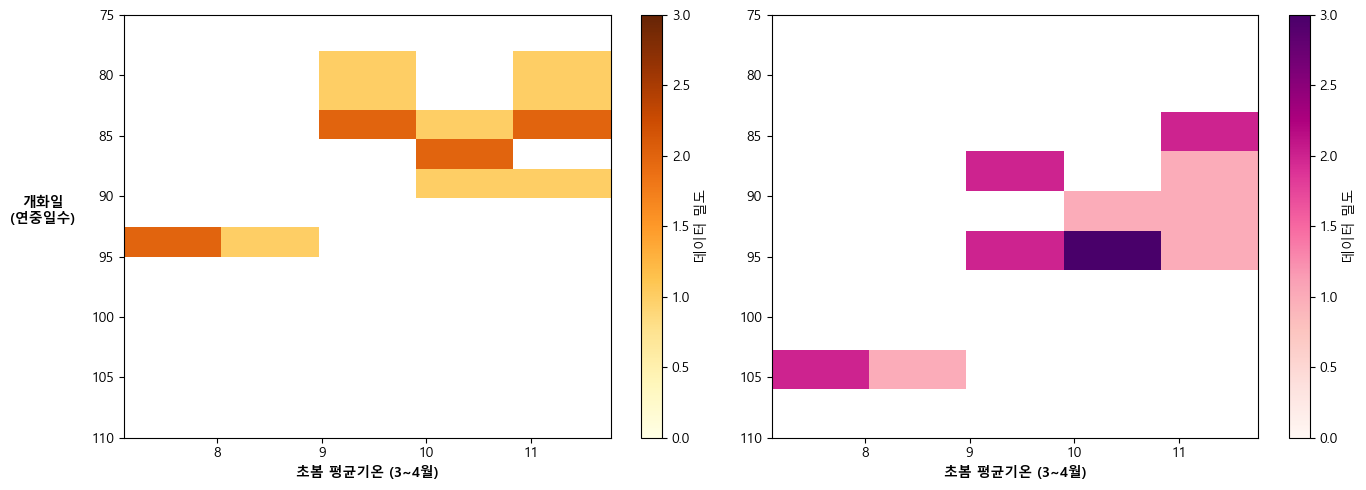

In [105]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

y_min = 75
y_max = 110

# 🔥 밀도 범위 설정 (최대값 기준)
vmax = 3  # 데이터에 맞게 조정 (보통 2~3이면 충분)
norm = Normalize(vmin=0, vmax=vmax)

# ======================
# 🔹 [왼쪽] 개나리
# ======================
ax = axes[0]

h1 = ax.hist2d(
    analysis_df34['spring_avg_temp_34'],
    analysis_df34['forsythia_doy'],
    bins=(5, 7),
    cmap='YlOrBr',
    cmin=1,
    norm=norm   # 🔥 정규화 적용
)

ax.set_xlabel('초봄 평균기온 (3~4월)', fontweight='bold')
ax.set_ylabel('개화일\n(연중일수)', rotation=0, labelpad=35, fontweight='bold')
ax.set_ylim(y_max, y_min)

# 🔥 컬러바 0.5 단위
cbar1 = plt.colorbar(h1[3], ax=ax)
cbar1.set_label('데이터 밀도')
cbar1.set_ticks(np.arange(0, vmax + 0.5, 0.5))

# ======================
# 🔹 [오른쪽] 벚나무
# ======================
ax = axes[1]

h2 = ax.hist2d(
    analysis_df34['spring_avg_temp_34'],
    analysis_df34['cherry_doy'],
    bins=(5, 7),
    cmap='RdPu',
    cmin=1,
    norm=norm
)

ax.set_xlabel('초봄 평균기온 (3~4월)', fontweight='bold')
ax.set_ylim(y_max, y_min)

cbar2 = plt.colorbar(h2[3], ax=ax)
cbar2.set_label('데이터 밀도')
cbar2.set_ticks(np.arange(0, vmax + 0.5, 0.5))

# ======================
# 레이아웃
# ======================
plt.tight_layout()
plt.show()

### 추가 시각화>>
- 기온과 벚나무개화시기, 개나리개화시기의 차이가 얼마나 나는지

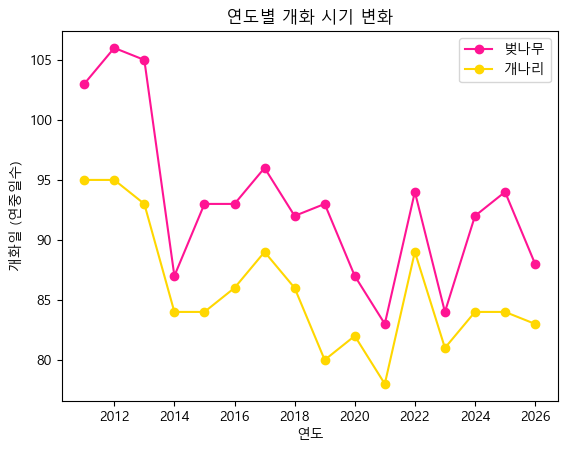

In [28]:
# 연도별 개화시기 비교
plt.figure()

plt.plot(
    analysis_df34['year'], 
    analysis_df34['cherry_doy'], 
    color='deeppink', 
    marker='o', 
    label='벚나무'
)

plt.plot(
    analysis_df34['year'], 
    analysis_df34['forsythia_doy'], 
    color='gold', 
    marker='o', 
    label='개나리'
)

plt.xlabel('연도')
plt.ylabel('개화일 (연중일수)')
plt.title('연도별 개화 시기 변화')
plt.legend()

plt.show()

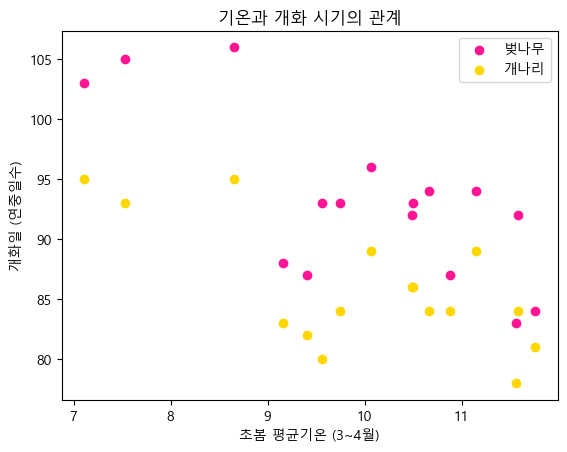

In [29]:
# 기온 vs개화시기
plt.figure()

# 벚나무
plt.scatter(
    analysis_df34['spring_avg_temp_34'],
    analysis_df34['cherry_doy'],
    color='deeppink',
    label='벚나무'
)

# 개나리
plt.scatter(
    analysis_df34['spring_avg_temp_34'],
    analysis_df34['forsythia_doy'],
    color='gold',
    label='개나리'
)

plt.xlabel('초봄 평균기온 (3~4월)')
plt.ylabel('개화일 (연중일수)')
plt.title('기온과 개화 시기의 관계')
plt.legend()

plt.show()

### 가설> 기온이 증가함에 따라 벚나무와 개나리의 개화시기가 비슷한가?
- 결론 : 두꽃의 개화시기가 동시에 앞당겨지는 경향은 있지만, 서로 비슷해진다고 보기는 어렵다.

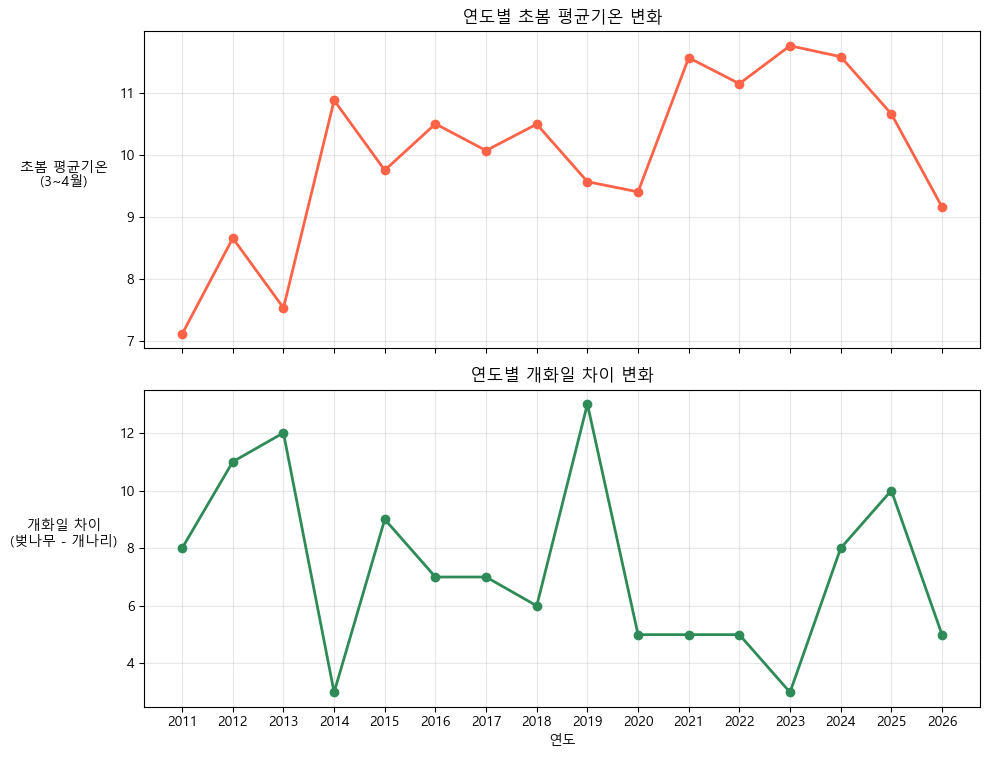

In [74]:
import matplotlib.pyplot as plt

# ======================
# 데이터
# ======================
x = analysis_df34['year']
temp = analysis_df34['spring_avg_temp_34']
gap = analysis_df34['bloom_gap']

# ======================
# subplot 생성
# ======================
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# ======================
# 위: 평균기온
# ======================
axes[0].plot(
    x,
    temp,
    marker='o',
    color='tomato',
    linewidth=2
)

axes[0].set_ylabel('초봄 평균기온\n(3~4월)', rotation=0, labelpad=40)
axes[0].set_title('연도별 초봄 평균기온 변화')
axes[0].grid(True, alpha=0.3)

# ======================
# 아래: 개화시기 차이
# ======================
axes[1].plot(
    x,
    gap,
    marker='o',
    color='seagreen',
    linewidth=2
)

axes[1].set_xlabel('연도')
axes[1].set_ylabel('개화일 차이\n(벚나무 - 개나리)', rotation=0, labelpad=40)
axes[1].set_title('연도별 개화일 차이 변화')
axes[1].grid(True, alpha=0.3)

# ======================
# 🔥 x축 연도 전부 표시
# ======================
axes[1].set_xticks(x)

# ======================
# 전체 제목
# ======================
#fig.suptitle('연도별 평균기온과 개화 시기 차이 변화', fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()